# Aula – Z-Score: Padronização, Interpretação e Detecção de Anomalias

## UC4 – Estatística aplicada à Inteligência Artificial

### Objetivos da aula
- Compreender o conceito de z-score.
- Interpretar valores acima, abaixo ou próximos da média.
- Entender a relação entre média, desvio padrão e z-score.
- Identificar possíveis outliers usando z-score.
- Aplicar z-score em situações reais de análise de dados.
- Relacionar z-score com preparação de dados para Inteligência Artificial.
- Resolver exercícios de cálculo, interpretação e aplicação prática.

## 1. Revisão rápida

Antes de entender z-score, precisamos lembrar dois conceitos:

### Média
A média mostra o centro dos dados.

### Desvio padrão
O desvio padrão mostra o quanto os dados se afastam da média.

### Ideia central
A média responde:

> Onde os dados estão concentrados?

O desvio padrão responde:

> O quanto os dados variam em torno da média?

O z-score responde:

> Um valor específico está quantos desvios padrão distante da média?

In [12]:
import numpy as np

dados = [10, 12, 14, 16, 18]
media = np.mean(dados)
print(f"A média dos dados é: {media}")

A média dos dados é: 14.0


In [16]:
desvio_padrao = float(np.std(dados))
print(f"O desvio padrão dos dados é: {desvio_padrao:.2f}")

O desvio padrão dos dados é: 2.83


## 2. Por que precisamos do z-score?

Imagine a pergunta:

> A nota 8 é boa?

A resposta correta é: depende.

Depende:
- da média da turma;
- do desvio padrão da turma;
- da dificuldade da prova;
- do desempenho dos demais alunos.

O valor bruto sozinho nem sempre diz muita coisa. Precisamos analisar o valor em relação ao comportamento do grupo.

## 3. O que é z-score?

O z-score mede quantos desvios padrão um valor está distante da média.

### Fórmula

$$
z = \frac{x - \mu}{\sigma}
$$

Onde:

- \(x\) = valor observado;
- \(\mu\) = média;
- \(\sigma\) = desvio padrão.

### Interpretação simples

O z-score transforma um valor em uma posição relativa dentro da distribuição dos dados.

## 4. Como interpretar o z-score

### z = 0
O valor está exatamente na média.

### z > 0
O valor está acima da média.

### z < 0
O valor está abaixo da média.

### Quanto maior o valor absoluto de z
Mais distante o valor está da média.

Exemplos:
- z = 0,2: muito próximo da média.
- z = 1: 1 desvio padrão acima da média.
- z = -1: 1 desvio padrão abaixo da média.
- z = 3: 3 desvios padrão acima da média.
- z = -3: 3 desvios padrão abaixo da média.

## 5. Tabela de interpretação

| Z-score | Interpretação |
|---|---|
| z = 0 | Valor igual à média |
| 0 < z < 1 | Pouco acima da média |
| -1 < z < 0 | Pouco abaixo da média |
| 1 <= z < 2 | Acima da média |
| -2 < z <= -1 | Abaixo da média |
| 2 <= z < 3 | Valor incomum |
| -3 < z <= -2 | Valor incomum |
| z >= 3 | Possível outlier alto |
| z <= -3 | Possível outlier baixo |

Esses limites são regras práticas, não leis absolutas. A interpretação depende do contexto.

## 6. Exemplo manual

Considere os dados:

[10, 12, 14, 16, 18]

A média é 14.  
O desvio padrão é aproximadamente 2,83.

Vamos calcular o z-score do valor 18:

$$
z = \frac{18 - 14}{2,83}
$$

$$
z \approx 1,41
$$

Interpretação: o valor 18 está aproximadamente 1,41 desvios padrão acima da média.

In [ ]:
z_18 = (18 - media) / desvio_padrao
print(f"O z-score do valor 18 é: {z_18:.2f}")

O z-score do valor 18 é: 1.41


## 7. Calculando z-score para todos os valores

In [29]:
import pandas as pd
dados_df = pd.DataFrame(
    {
        'Dados': dados,
        'Z-Score': [(x - media) / desvio_padrao for x in dados]
    }
)
print(dados_df)

   Dados   Z-Score
0     10 -1.414214
1     12 -0.707107
2     14  0.000000
3     16  0.707107
4     18  1.414214


## 8. Interpretação dos resultados

No conjunto anterior:

- 14 tem z-score igual a 0, pois está na média.
- 18 tem z-score positivo, pois está acima da média.
- 10 tem z-score negativo, pois está abaixo da média.
- 10 e 18 têm a mesma distância da média, mas em lados opostos.

O sinal mostra a direção. O tamanho do número mostra a distância.

## 9. Comparação entre alunos

Vamos comparar dois alunos que tiraram a mesma nota: 8.

### Aluno A
- nota = 8
- média da turma = 7
- desvio padrão = 0,5

### Aluno B
- nota = 8
- média da turma = 6
- desvio padrão = 2

Pergunta:

> Quem teve melhor desempenho em relação à própria turma?

In [34]:
notaA = 8
mediaA = 7
desvio_padraoA = 0.5

z_notaA = (notaA - mediaA) / desvio_padraoA
print(f"O z-score da nota A é: {z_notaA:.2f}")
coeficiente_de_variacaoA = (desvio_padraoA / mediaA) * 100
print(f"O coeficiente de variação do aluno da turma A é: {coeficiente_de_variacaoA:.2f}%")

O z-score da nota A é: 2.00
O coeficiente de variação do aluno da turma A é: 7.14%


In [35]:
notaB = 8
mediaB = 6
desvio_padraoB = 2

z_notaB = (notaB - mediaB) / desvio_padraoB
print(f"O z-score da nota B é: {z_notaB:.2f}")
coeficiente_de_variacaoB = (desvio_padraoB / mediaB) * 100
print(f"O coeficiente de variação do aluno da turma B é: {coeficiente_de_variacaoB:.2f}%")

O z-score da nota B é: 1.00
O coeficiente de variação do aluno da turma B é: 33.33%


## 10. Interpretação da comparação

### Aluno A
z = 2

A nota dele está 2 desvios padrão acima da média da turma.

### Aluno B
z = 1

A nota dele está 1 desvio padrão acima da média da turma.

Conclusão: apesar dos dois terem tirado 8, o Aluno A teve desempenho mais destacado em relação à turma dele.

Isso mostra uma das maiores utilidades do z-score:

> Comparar valores em contextos diferentes.

## 11. Exemplo prático: tempo de atendimento

Uma empresa mede o tempo de atendimento de chamados, em minutos:

[8, 9, 10, 10, 11, 12, 45]

Pergunta:

> O tempo 45 é normal ou está fora do padrão?

In [40]:
tempo_atendimento = [8, 9, 10, 10, 11, 12, 45]
media_tempo = np.mean(tempo_atendimento)
desvio_padrao_tempo = np.std(tempo_atendimento)
print(f"media: {media_tempo:.2f}, desvio padrão: {desvio_padrao_tempo:.2f}")
z_scores_tempo = [(x - media_tempo) / desvio_padrao_tempo for x in tempo_atendimento]
tempo_df = pd.DataFrame({
    'Tempo de Atendimento': tempo_atendimento,
    'Z-Score': z_scores_tempo
})
tempo_df

media: 15.00, desvio padrão: 12.31


,Tempo de Atendimento,Z-Score
0,8,-0.568845
1,9,-0.487582
2,10,-0.406318
3,10,-0.406318
4,11,-0.325054
5,12,-0.243791
6,45,2.437908


## 12. Interpretando o tempo de atendimento

O valor 45 é muito maior do que os demais tempos.

O z-score ajuda a quantificar o quanto ele está distante da média.

Na rotina de trabalho, isso poderia indicar:
- atendimento anormal;
- problema no processo;
- chamado complexo;
- erro no registro;
- gargalo operacional.

Um outlier não deve ser removido automaticamente. Primeiro, ele deve ser investigado.

## 13. Regra empírica: 68%, 95%, 99,7%

Quando os dados seguem aproximadamente uma distribuição normal, podemos usar a regra empírica:

- cerca de 68% dos dados ficam entre -1 e +1 desvio padrão;
- cerca de 95% dos dados ficam entre -2 e +2 desvios padrão;
- cerca de 99,7% dos dados ficam entre -3 e +3 desvios padrão.

Se um valor tem z-score maior que 3 ou menor que -3, ele é bastante incomum.

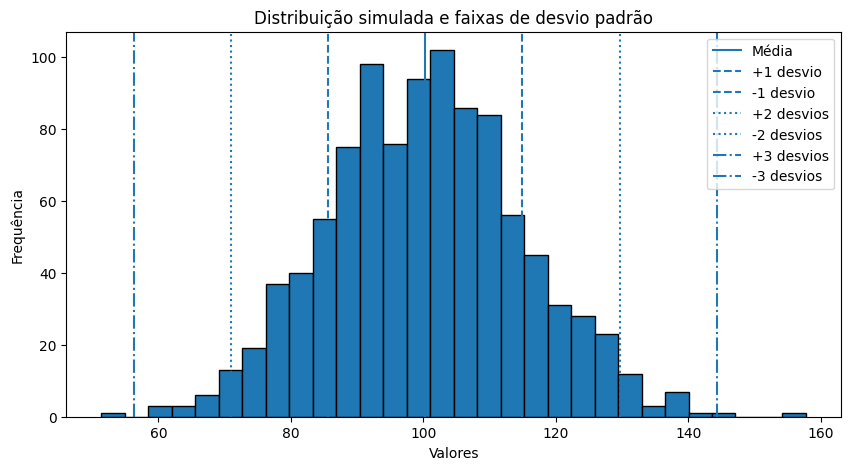

In [43]:
import matplotlib.pyplot as plt

np.random.seed(42)

dados_normais = np.random.normal(loc=100, scale=15, size=1000)

media = np.mean(dados_normais)
desvio = np.std(dados_normais)

plt.figure(figsize=(10, 5))
plt.hist(dados_normais, bins=30, edgecolor="black")

plt.axvline(media, linestyle="-", label="Média")
plt.axvline(media + desvio, linestyle="--", label="+1 desvio")
plt.axvline(media - desvio, linestyle="--", label="-1 desvio")
plt.axvline(media + 2*desvio, linestyle=":", label="+2 desvios")
plt.axvline(media - 2*desvio, linestyle=":", label="-2 desvios")
plt.axvline(media + 3*desvio, linestyle="-.", label="+3 desvios")
plt.axvline(media - 3*desvio, linestyle="-.", label="-3 desvios")

plt.title("Distribuição simulada e faixas de desvio padrão")
plt.xlabel("Valores")
plt.ylabel("Frequência")
plt.legend()
plt.show()

## 14. Z-score e outliers

Uma regra prática comum:

- |z| > 2: valor suspeito.
- |z| > 3: possível outlier.

O símbolo |z| significa valor absoluto.

Exemplo:
- z = 3,2: possível outlier.
- z = -3,5: possível outlier.
- z = 0,4: valor próximo da média.

Nem todo valor extremo é erro. Pode ser fraude, evento raro, cliente especial, erro de cadastro ou comportamento legítimo, mas incomum.

In [49]:
dados = [10, 12, 13, 14, 100]

media = np.mean(dados)
desvio = np.std(dados)

df = pd.DataFrame({
    "valor": dados,
    "z_score": [(x - media) / desvio for x in dados],
})

df["abs_z"] = df["z_score"].abs()
df["suspeito_abs_maior_2"] = df["abs_z"] > 2
df["possivel_outlier_abs_maior_3"] = df["abs_z"] > 3

media, desvio, df

(np.float64(29.8),
 np.float64(35.12491992873436),
    valor   z_score     abs_z  suspeito_abs_maior_2  \
 0     10 -0.563702  0.563702                 False   
 1     12 -0.506763  0.506763                 False   
 2     13 -0.478293  0.478293                 False   
 3     14 -0.449823  0.449823                 False   
 4    100  1.998581  1.998581                 False   
 
    possivel_outlier_abs_maior_3  
 0                         False  
 1                         False  
 2                         False  
 3                         False  
 4                         False  )

## 15. Cuidado importante

Em conjuntos pequenos, o z-score pode não marcar claramente um outlier, porque o próprio valor extremo aumenta a média e o desvio padrão.

Isso pode mascarar o problema.

Por isso, em análise real, é comum usar também:
- quartis;
- boxplot;
- IQR;
- conhecimento do negócio;
- regras específicas do contexto.

Conclusão: z-score é poderoso, mas não deve ser usado isoladamente.

## 16. Z-score e padronização

Z-score também é usado para padronizar dados.

Padronizar significa transformar uma variável para que ela tenha:
- média 0;
- desvio padrão 1.

Isso ajuda modelos de IA porque coloca variáveis diferentes em uma escala comparável.

Exemplo: um dataset com idade, salário e quantidade de compras. Essas variáveis estão em escalas completamente diferentes. O z-score ajuda a colocar todas em uma escala comum.

In [50]:
df = pd.DataFrame({
    "idade": [20, 25, 30, 35, 40],
    "salario": [2000, 3000, 4000, 5000, 6000],
    "compras": [1, 3, 4, 6, 8]
})

df

,idade,salario,compras
0,20,2000,1
1,25,3000,3
2,30,4000,4
3,35,5000,6
4,40,6000,8


In [51]:
df_padronizado = (df - df.mean()) / df.std(ddof=0)
df_padronizado

,idade,salario,compras
0,-1.414214,-1.414214,-1.406930
1,-0.707107,-0.707107,-0.579324
2,0.000000,0.000000,-0.165521
3,0.707107,0.707107,0.662085
4,1.414214,1.414214,1.489691


## 17. Interpretação da padronização

Depois da padronização:

- valores positivos estão acima da média da coluna;
- valores negativos estão abaixo da média da coluna;
- valores próximos de zero estão próximos da média;
- todas as variáveis passam a ser comparáveis em termos de desvio padrão.

Isso é muito usado antes de aplicar algoritmos como:
- KNN;
- regressão;
- redes neurais;
- clustering;
- PCA.

## 18. Aplicações em Inteligência Artificial

### 1. Normalização / padronização de variáveis
Algoritmos podem ser prejudicados quando uma variável tem escala muito maior que outra.

Exemplo:
- salário varia de 2000 a 10000;
- idade varia de 18 a 60.

Sem padronizar, o salário pode dominar o modelo.

### 2. Detecção de anomalias
Valores com z-score muito alto ou baixo podem indicar comportamento fora do padrão.

Exemplo:
- transação financeira incomum;
- tempo de resposta anormal;
- erro de sensor;
- atividade suspeita.

### 3. Comparação justa
O z-score permite comparar valores de contextos diferentes.

Exemplo:
- notas de turmas diferentes;
- vendas de lojas diferentes;
- desempenho de equipes diferentes.

### 4. Pré-processamento de dados
Antes de treinar modelos, o z-score pode ajudar a preparar os dados.

## 19. Aplicação na rotina de trabalho

O z-score pode ser usado para responder perguntas como:

### Em sistemas
- esse tempo de resposta está muito acima do normal?
- esse consumo de CPU está fora do padrão?
- esse erro ocorreu em frequência anormal?

### Em processos
- esse processo demorou muito mais que os demais?
- esse valor de causa está fora do padrão?
- essa quantidade de movimentações é incomum?

### Em negócios
- essa venda é atípica?
- esse cliente comprou muito acima do normal?
- esse preço está fora da faixa comum?

### Em educação
- essa nota está muito acima ou abaixo da turma?
- uma turma é mais homogênea que outra?
- um aluno teve desempenho realmente excepcional?

# Exercícios resolvidos

## Exercício resolvido 1

Dados:
[10, 12, 14, 16, 18]

Calcule o z-score do valor 18.

Média = 14  
Desvio padrão ≈ 2,83

\[
z = \frac{18 - 14}{2,83} \approx 1,41
\]

Interpretação: o valor 18 está 1,41 desvios padrão acima da média.

In [ ]:
dados = [10, 12, 14, 16, 18]
media = np.mean(dados)
desvio = np.std(dados)

(18 - media) / desvio

## Exercício resolvido 2

Um aluno tirou nota 9.

A turma teve:
- média 7;
- desvio padrão 1.

\[
z = \frac{9 - 7}{1} = 2
\]

Interpretação: o aluno está 2 desvios padrão acima da média da turma.

In [ ]:
(9 - 7) / 1

# Lista de exercícios

## Parte A – Conceitos

### Exercício 1
Explique, com suas palavras, o que é z-score.

### Exercício 2
O que significa z-score igual a zero?

### Exercício 3
O que significa um z-score positivo?

### Exercício 4
O que significa um z-score negativo?

### Exercício 5
Qual valor está mais distante da média?
- z = 1,2
- z = -2,4
- z = 0,5

Justifique.

### Exercício 6
Por que o z-score permite comparar valores de contextos diferentes?

### Exercício 7
Por que z-score pode ser útil em Inteligência Artificial?

In [ ]:
# Exercício 1: É um tipo de transformação que pode ser aplicada aos dados, como objetivos de verificar a existência de outliers caso o resultado da transformação seja maior que 3.

In [ ]:
# Exercício 2: Significa que o valor que foi transformado tem o mesmo valor da média.

In [ ]:
# Exercício 3: Significa que o valor transformado possui um valor maior do que a média.

In [ ]:
# Exercício 4: Significa que o valor transformado possui um valor menor do que a média.

In [ ]:
# Exercício 5: O valor mais distante da média é o z = -2.4 por ser o maior valor dentre os 3 aprensentados, em módulo.

In [ ]:
# Exercício 6: Porque toda variável transformada em z-escore terá média = 0 e desvio padrão = 1.

In [ ]:
# Exercício 7: É util pois pode ajudar a identificar a possíveis outliers na base de dados de treinamento que poderiam diminuir a qualidade da IA.

## Parte B – Cálculo manual

### Exercício 8
Um conjunto tem média = 50 e desvio padrão = 10. Calcule o z-score de x = 70.

### Exercício 9
Um conjunto tem média = 100 e desvio padrão = 20. Calcule o z-score de x = 60.

### Exercício 10
Um conjunto tem média = 30 e desvio padrão = 5. Calcule o z-score de x = 30.

### Exercício 11
Um aluno tirou 8. A média da turma foi 6. O desvio padrão foi 1. Calcule o z-score e interprete.

### Exercício 12
Um atendimento levou 25 minutos. A média dos atendimentos é 15 minutos. O desvio padrão é 5 minutos. Calcule o z-score e interprete.

In [57]:
# Exercício 8: 
media = 50
desvio_padrao = 10
x = 70
z_escore = (x - media)/desvio_padrao
print(f"O z-escore é {z_escore}")

O z-escore é 2.0


In [56]:
# Exercício 9: 
media = 100
desvio_padrao = 20
x = 60
z_escore = (x - media)/desvio_padrao
print(f"O z-escore é {z_escore}")

O z-escore é -2.0


In [58]:
# Exercício 10: 
media = 30
desvio_padrao = 5
x = 30
z_escore = (x - media)/desvio_padrao
print(f"O z-escore é {z_escore}")

O z-escore é 0.0


In [ ]:
nota_aluno = 8
media_turma = 6
desvio_padrao_turma = 1

z_escore_nota = (nota_aluno - media_turma)/desvio_padrao_turma
print(f"O z-escore é {z_escore_nota}")

# O resultado do z-escore foi positivo, logo a nota do aluno foi maior do que a nota. 
# Como o resultado foi de z = 2, isso significa a nota do aluno está a dois desvios padrão da média.

O z-escore é 2.0


## Parte C – Interpretação

### Exercício 13
Um valor tem z-score = 2,8. O que isso indica?

### Exercício 14
Um valor tem z-score = -3,2. O que isso indica?

### Exercício 15
Um valor tem z-score = 0,1. Ele parece incomum? Explique.

### Exercício 16
Um valor tem z-score = 4. Você removeria automaticamente esse valor? Por quê?

### Exercício 17
Em um sistema de monitoramento, o tempo de resposta de uma API apresentou z-score = 3,5. O que isso pode indicar?

In [ ]:
# Exercício 13: Significa que o valor está à 2.8 desvios padrões da média e pode ser considerado um possível outlier.

In [ ]:
# Exercício 14: Significa que o valor está à 3.2 desvios padrões da média e pode ser considerado um outlier.

In [ ]:
# Exercício 15: Não é o valor incomum, mas indica que o valor é bem próximo da média.

In [ ]:
# Exercício 16: Sim, pois caso o valor seja acima de 3, ele já seria maior do que 99.7% dos dados, com esse valor de z as chances desse valor ser um outlier é muito alta.

In [ ]:
# Exercício 17: Isso pode indicar que o tempo de resposta observado, está fora do padrão esperado. Sinalizando um possível problema.

## Parte D – Comparação entre contextos

### Exercício 18
Aluno A:
- nota = 8
- média da turma = 7
- desvio padrão = 0,5

Aluno B:
- nota = 8
- média da turma = 6
- desvio padrão = 2

Quem teve melhor desempenho relativo? Justifique.

### Exercício 19
Loja A vendeu R$ 10.000 em um dia. A média da loja é R$ 8.000 e o desvio padrão é R$ 1.000.

Loja B vendeu R$ 10.000 em um dia. A média da loja é R$ 9.500 e o desvio padrão é R$ 2.000.

Qual venda foi mais fora do padrão?

In [ ]:
# Exercício 18
notaA = 8
media_turmaA = 7
dp_A = 0.5

notaB = 8
media_turmaB = 6
dp_B = 2

z_A = (notaA - media_turmaA)/dp_A
z_B = (notaB - media_turmaB)/dp_B

print(f"Z-score do aluno A: {z_A:.2f}")
print(f"Z-score do aluno B: {z_B:.2f}")

# Como o valor do z-escore da nota do aluno A é maior que a do aluno B, 
# pois o valor do z-escore do aluno A é 2, indicando que a nota do aluno A está a 2 desvios padrões acima da média,
# enquanto a nota do aluno B está a apenas 1 desvio padrão acima da média.

Z-score do aluno A: 2.00
Z-score do aluno B: 1.00


In [ ]:
venda_loja_A = 10000
media_loja_A = 8000
desvio_padrao_loja_A = 1000

venda_loja_B = 10000
media_loja_B = 9500
desvio_padrao_loja_B = 2000

z_A = (venda_loja_A - media_loja_A)/desvio_padrao_loja_A
z_B = (venda_loja_B - media_loja_B)/desvio_padrao_loja_B

print(f"Z-score da loja A: {z_A:.2f}")
print(f"Z-score da loja B: {z_B:.2f}")

# A loja A tem um z-escore maior do que a loja B, pois seu valor de z é 2,
# indicando que a venda da loja A está a 2 desvios padrões acima da média, enquanto a venda da loja B está a apenas 0.25 desvios padrões acima da média.

Z-score da loja A: 2.00
Z-score da loja B: 0.25


## Parte E – Python

### Exercício 20
Calcule os z-scores para:

[2, 4, 6, 8, 10]

In [ ]:
dados = [2, 4, 6, 8, 10]

media = np.mean(dados)
desvio = np.std(dados)

[(x, (x - media) / desvio) for x in dados]

### Exercício 21
Calcule os z-scores para:

[50, 55, 60, 65, 70]

In [ ]:
dados = [50, 55, 60, 65, 70]

media = np.mean(dados)
desvio = np.std(dados)

[(x, (x - media) / desvio) for x in dados]

### Exercício 22
Analise os tempos de resposta:

[100, 110, 105, 115, 120, 500]

Calcule os z-scores e interprete se há algum valor incomum.

In [ ]:
tempos = [100, 110, 105, 115, 120, 500]

media = np.mean(tempos)
desvio = np.std(tempos)

pd.DataFrame({
    "tempo": tempos,
    "z_score": [(x - media) / desvio for x in tempos]
})

### Exercício 23
Padronize o seguinte DataFrame usando z-score.

In [ ]:
df = pd.DataFrame({
    "idade": [18, 25, 30, 45, 60],
    "salario": [1500, 2500, 4000, 7000, 12000],
    "compras": [1, 2, 3, 8, 15]
})

df

In [ ]:
df_padronizado = (df - df.mean()) / df.std(ddof=0)
df_padronizado

### Perguntas do Exercício 23
1. Qual valor está mais acima da média em salário?
2. Qual valor está mais abaixo da média em idade?
3. Após padronizar, por que as variáveis ficaram comparáveis?

## Parte F – Aplicação em IA

### Exercício 24
Explique por que algoritmos como KNN podem ser prejudicados se uma variável tiver escala muito maior que outra.

### Exercício 25
Explique como o z-score pode ajudar a detectar uma transação financeira suspeita.

### Exercício 26
Explique por que nem todo outlier deve ser removido automaticamente.

### Exercício 27
Dê um exemplo de uso de z-score na sua rotina profissional ou acadêmica.

# Desafio final – Caso aplicado

Uma empresa monitora o tempo de resposta de uma API em milissegundos.

Os tempos observados foram:

[210, 215, 220, 218, 222, 219, 217, 800]

## Tarefas
1. Calcule a média.
2. Calcule o desvio padrão.
3. Calcule o z-score de cada valor.
4. Identifique o valor mais incomum.
5. Explique se esse valor deve ser investigado.
6. Relacione essa análise com monitoramento de sistemas.
7. Explique como isso poderia ser usado em uma solução de IA para detecção de anomalias.

In [ ]:
tempos_api = [210, 215, 220, 218, 222, 219, 217, 800]

media = np.mean(tempos_api)
desvio = np.std(tempos_api)

df_api = pd.DataFrame({
    "tempo_ms": tempos_api,
    "z_score": [(x - media) / desvio for x in tempos_api],
})

df_api["abs_z"] = df_api["z_score"].abs()

media, desvio, df_api.sort_values("abs_z", ascending=False)

# Gabarito curto – ideias principais

- z-score mede quantos desvios padrão um valor está distante da média.
- z-score positivo indica valor acima da média.
- z-score negativo indica valor abaixo da média.
- z-score próximo de zero indica valor próximo da média.
- valores com |z| alto são mais incomuns.
- z-score pode ajudar na detecção de outliers.
- z-score também é usado para padronizar dados.
- em IA, padronização pode melhorar o desempenho de alguns algoritmos.
- outliers devem ser investigados antes de serem removidos.

# Fechamento

Nesta aula, estudamos o z-score como ferramenta para:

- interpretar valores em relação à média;
- medir distância em desvios padrão;
- comparar contextos diferentes;
- identificar possíveis outliers;
- padronizar dados;
- preparar dados para modelos de IA.

A grande mudança de pensamento é:

> Em vez de perguntar apenas se um valor é alto ou baixo, passamos a perguntar: quantos desvios padrão esse valor está distante da média?